In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.getcwd()))

from research_agent import build_agent, interviewBuilder

agent = build_agent()
builder = interviewBuilder()

graph = agent.get_graph()
builder_graph = builder.get_graph()

print(f"Agent compiled. Nodes: {list(agent.nodes.keys())}")
print(f"Builder compiled. Nodes: {list(builder_graph.nodes.keys())}")

Agent compiled. Nodes: ['__start__', 'create_analysts', 'conduct_interview', 'write_report', 'write_introduction', 'write_conclusion', 'finalize_report']
Builder compiled. Nodes: ['__start__', 'ask_question', 'search_web', 'answer_question', 'save_interview', 'write_section', '__end__']


In [ ]:
from IPython.display import Markdown

builder_mermaid_code = builder_graph.draw_mermaid()
display(Markdown(f"```mermaid\n{builder_mermaid_code}\n```"))

mermaid_code = graph.draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_code}\n```"))


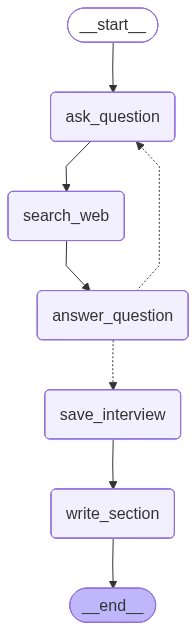

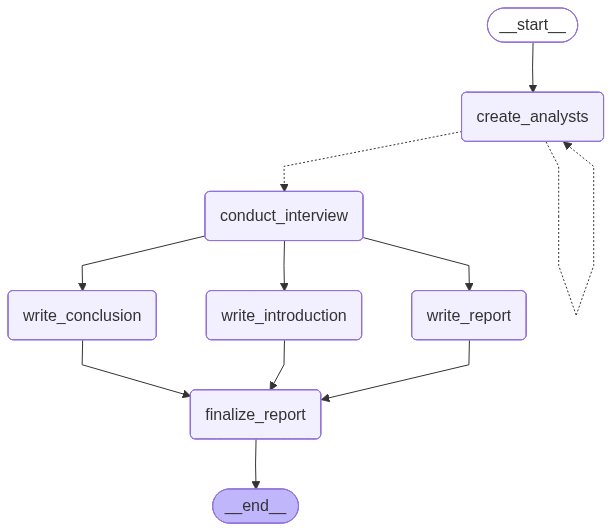

In [2]:
from IPython.display import Image

builder_png_data = builder_graph.draw_mermaid_png()
display(Image(builder_png_data))

png_data = graph.draw_mermaid_png()
display(Image(png_data))

## Deep Research

In [ ]:
# Inputs
max_analysts = 5
topic = "The convergence of ZK-proofs, decentralized physical infrastructure (DePIN), and AI agents as a new internet primitive"
word_count = 1000
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in agent.stream(
    {
        "topic":topic, 
        "max_analysts":max_analysts,
        "word_count":word_count
    }, 
    thread, 
    stream_mode="values"
):
    
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

In [ ]:
from IPython.display import Markdown
final_state = agent.get_state(thread)
report = final_state.values.get('final_report')
print(report)

## Medium Research

In [ ]:
thread = {"configurable": {"thread_id": "1"}}

result = await agent.ainvoke({
    "topic": "How lack of DeFi-To-Mobile-Money brdiges makes it hard for crypto holders "
    "in emerging markets to turn crypto into as asset that can be used as collateral to borrow fiat against, "
    "currently they have to juggle multiple apps to go from crypto tp fiat that is if not forced to sell!",
    "max_analysts": 5,
    "word_count": 1000,
}, thread)
report = result.get("final_report")

In [ ]:
print(report)

## Short/Quick Test

In [ ]:
thread = {"configurable": {"thread_id": "1"}}

result = await agent.ainvoke({
    "topic": "The environmental impact of Bitcoin mining in 2025",
    "max_analysts": 2,
    "word_count": 500,
}, thread)
report = result.get("final_report")

In [ ]:
print(report)